In [3]:
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt
import numpy as np

# Cycles moteurs au $CO_{2}$ supercritique #

## 1. Cycle de Brayton simple au $CO_{2}$ (gazeux) ##

*$\textbf{Q-1.1 :}$ Dessiner le cycle sur un diagramme (T-s) et faire le calcul complet des états (tableau 1) et des transformations (tableau 2).*

In [4]:
#Définition des constantes connues :
P_1 = 70.e5 #Pa
T_1 = 848 #K
P_3 = 10.e5 #Pa
T_3 = 303 #K

In [5]:
#Calcul des enthalpies et entropies
h_1= CP.PropsSI("H","P",P_1,"T",T_1,"CO2")
s_1 = CP.PropsSI("S","P",P_1,"H",h_1,"CO2")
h_3 = CP.PropsSI("H","P",P_3,"T",T_3,"CO2")
s_3 = CP.PropsSI("S","P",P_3,"H",h_3,"CO2")
print(f"h_1: {h_1*1e-3} kJ/kg", f"s_1: {s_1*1e-3} kJ/kg/K", f"h_3: {h_3*1e-3} kJ/kg", f"s_3: {s_3*1e-3} kJ/kg/K", sep="\n")

h_1: 1075.5167755789087 kJ/kg
s_1: 2.991627708649479 kJ/kg/K
h_3: 501.6007192973885 kJ/kg
s_3: 2.298529627716221 kJ/kg/K


• Transformation 1->2 :

 On suppose d'abord la transformation adiabatique réversible, c'est à dire isentropique. 

In [6]:
P_2 = P_3   
# Transformation supposée isentropique : s_2 = s_1  
T_2_is = CP.PropsSI("T", "P", P_2, "S", s_1, "CO2")
print(f"T_2_is = {T_2_is:.2f} K  ({T_2_is - 273.15:.2f} °C)")

h_2_is= CP.PropsSI("H","P",P_2,"T",T_2_is,"CO2")
print(f"h_2_is: {h_2_is*1e-3} kJ/kg")

T_2_is = 610.03 K  (336.88 °C)
h_2_is: 808.8685606403932 kJ/kg


On étudie maintenant la transformation réelle 1->2 : 

In [7]:
eta_t = 0.85 # rendement isentropique turbine 
h_2_reel = h_1 - eta_t * (h_1 - h_2_is)
print(f"h_2_reel: {h_2_reel*1e-3} kJ/kg")

T_2 = CP.PropsSI("T", "P", P_2, "H", h_2_reel, "CO2")
print(f"T_2 = {T_2:.2f} K  ({T_2 - 273.15:.2f} °C)")

s_2 = CP.PropsSI("S","P",P_2,"H",h_2_reel,"CO2")
print(f"s_2: {s_2*1e-3} kJ/kg/K")

h_2_reel: 848.8657928811706 kJ/kg
T_2 = 646.47 K  (373.32 °C)
s_2: 3.055304815340956 kJ/kg/K


• Transformation 3->4:

De manière analogue, on suppose d'abord la transformation 3->4 isentropique.

In [8]:
P_4 = P_1
T_4_is = CP.PropsSI("T", "P", P_4, "S", s_3, "CO2")
print(f"T_4_is = {T_4_is:.2f} K  ({T_4_is - 273.15:.2f} °C)")

h_4_is= CP.PropsSI("H","P",P_4,"T",T_4_is,"CO2")
print(f"h_4_is: {h_4_is*1e-3} kJ/kg")

T_4_is = 463.43 K  (190.28 °C)
h_4_is: 632.4325566799653 kJ/kg


Pour la transformation réelle 3->4 : 

In [9]:
eta_c = 0.8 # rendement isentropique compresseur 
h_4_reel = h_3 + (h_4_is - h_3)/eta_c
print(f"h_4_reel: {h_4_reel*1e-3} kJ/kg")

T_4 = CP.PropsSI("T", "P", P_4, "H", h_4_reel, "CO2")
print(f"T_4 = {T_4:.2f} K  ({T_4 - 273.15:.2f} °C)")

s_4 = CP.PropsSI("S","P",P_4,"H",h_4_reel,"CO2")
print(f"s_4: {s_4*1e-3} kJ/kg/K")

h_4_reel: 665.1405160256095 kJ/kg
T_4 = 492.72 K  (219.57 °C)
s_4: 2.3669687237051704 kJ/kg/K


/var/folders/bv/ykzk9d_14271yt6j934j38jw0000gn/T/ipykernel_11052/3794019479.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([points_s[0], points_s[0]], [points_T[0], T_2_is],'k--', color='black', label='transforation isentropique')
/var/folders/bv/ykzk9d_14271yt6j934j38jw0000gn/T/ipykernel_11052/3794019479.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([points_s[2], points_s[2]], [points_T[2], T_4_is], 'k--', color='black')


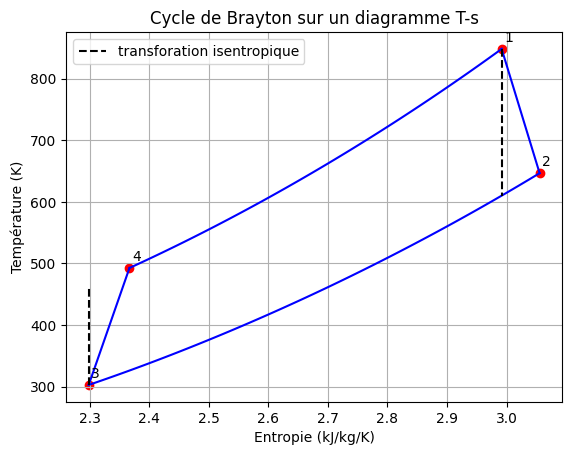

In [10]:
points_s = [s_1*1e-3, s_2*1e-3, s_3*1e-3, s_4*1e-3]
points_T = [T_1, T_2, T_3, T_4]
points_P= [P_1, P_2, P_3, P_4]

# Programme pour tracer les isobares
def transfo_isobare(T_in, T_out, P, n=100):
    Ss, Ts = [], []
    for t in np.linspace(T_in, T_out, n):
        try:
            s_val = CP.PropsSI("S", "P", P, "T", t, "CO2") * 1e-3  # Conversion en kJ/kg/K
            Ss.append(s_val)
            Ts.append(t)
        except:
            pass
    return [np.array(Ss), np.array(Ts)]

# Affichage des 4 points états
plt.scatter(points_s, points_T, marker='o', color='red')
for i, txt in enumerate(['1', '2', '3', '4']):
    plt.annotate(txt, (points_s[i], points_T[i]), textcoords="offset points", xytext=(5,5), ha='center')
# Tracé des isobares
S_23, T_23 = transfo_isobare( T_2, T_3, P_2)
plt.plot(S_23, T_23, color='blue')
S_41, T_41 = transfo_isobare(T_4, T_1, P_4)
plt.plot(S_41, T_41, color='blue')
# Tracé des transformations réelles
plt.plot([points_s[0], points_s[1]], [points_T[0], points_T[1]], color='blue')
plt.plot([points_s[2], points_s[3]], [points_T[2], points_T[3]], color='blue')
# Tracé des transformations isentropiques
plt.plot([points_s[0], points_s[0]], [points_T[0], T_2_is],'k--', color='black', label='transforation isentropique')
plt.plot([points_s[2], points_s[2]], [points_T[2], T_4_is], 'k--', color='black')

# Affichage du diagramme
plt.xlabel('Entropie (kJ/kg/K)')
plt.ylabel('Température (K)')
plt.title('Cycle de Brayton sur un diagramme T-s')
plt.legend()
plt.grid()
plt.show()

On peut à présent remplir le tableau 2 : 

In [11]:
q_m = 100 # kg/s

# Echange d'énergie :
print("Echange d'énergie :",
      f"Chaudière : {q_m*(h_4_reel-h_1)*1e-6} MW",
      f"Turbine : {q_m*(h_1-h_2_reel)*1e-6} MW",
      f"Source froide :{q_m*(h_2_reel-h_3)*1e-6} MW",
      f"Compresseur : {q_m*(h_3-h_4_reel)*1e-6} MW", sep="\n")

# Puissance thermique :
q_chaude = (h_1-h_4_reel)*q_m*1e-6
q_froide = (h_3-h_2_reel)*q_m*1e-6
print("Puissance tyhermique :",
      f"Chaudière : {q_chaude} MW",
      f"Turbine : 0 MW car adiabatique",
      f"Source froide : {q_froide} MW",
      f"Compresseur : 0 MW car adiabatique", sep="\n")

# Travail utile :
w_turbine = (h_2_reel-h_1)*q_m*1e-6
w_compresseur = (h_4_reel-h_3)*q_m*1e-6
print("Travail utile :",
      f"Chaudière : 0 MW car pas de travail",
      f"Turbine : {w_turbine} MW",
      f"Source froide : 0 MW car pas de travail ",
      f"Compresseur : {w_compresseur} MW", sep="\n")

# Echange d'éxergie :
T0 = 280 #K, fixé arbitrairement selon la page 32 du cours. 
print("Echange d'éxergie :",
      f"Chaudière : {q_m*((h_4_reel-h_1)-T0*(s_4-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6} MW",
      f"Source froide :{q_m*((h_2_reel-h_3)-T0*(s_2-s_3))*1e-6} MW",
      f"Compresseur : {q_m*((h_3-h_4_reel)-T0*(s_3-s_4))*1e-6} MW", sep="\n")

# Exergie des échanges :
T_froide = 293.15 # K, source froide 
T_chaude = 873.15 # K, source chaude
eta_Carnot = 1 - T_froide / T_chaude
print("Exergie des échanges :",
      f"Chaudière : {q_chaude*eta_Carnot} MW",
      f"Source froide : {q_froide*eta_Carnot} MW",sep="\n")

# Destruction d'exergie :
print("Destruction d'exergie :",
      f"Chaudière : {q_m*((h_4_reel-h_1)-T0*(s_4-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6-w_turbine}MW",
      f"Source froide :{q_m*((h_2_reel-h_3)-T0*(s_2-s_3))*1e-6} MW",
      f"Compresseur : {q_m*((h_3-h_4_reel)-T0*(s_3-s_4))*1e-6-w_compresseur} MW", sep="\n")


Echange d'énergie :
Chaudière : -41.037625955329915 MW
Turbine : 22.66509826977381 MW
Source froide :34.72650735837821 MW
Compresseur : -16.3539796728221 MW
Puissance tyhermique :
Chaudière : 41.037625955329915 MW
Turbine : 0 MW car adiabatique
Source froide : -34.72650735837821 MW
Compresseur : 0 MW car adiabatique
Travail utile :
Chaudière : 0 MW car pas de travail
Turbine : -22.66509826977381 MW
Source froide : 0 MW car pas de travail 
Compresseur : 16.3539796728221 MW
Echange d'éxergie :
Chaudière : -23.54717437688928 MW
Turbine : 24.448057257135165 MW
Source froide :13.536802104885632 MW
Compresseur : -14.43768498513152 MW
Exergie des échanges :
Chaudière : 27.25971832341677 MW
Source froide : -23.067484702352814 MW
Destruction d'exergie :
Chaudière : -23.54717437688928 MW
Turbine : 47.113155526908976MW
Source froide :13.536802104885632 MW
Compresseur : -30.791664657953618 MW


*$\textbf{Q-1.2 :}$ Calculer les rendements énergétique et exergétique.*

• Rendement énergétique

Pour calculer le rendement énergétique, on a besoin de connaître la puissance délivrée et la chaleur délivrée par le système.

In [12]:
w_net = w_compresseur + w_turbine        # MW
print(f"w_turbine = {w_turbine:.1f} MW")
print(f"w_compresseur = {w_compresseur:.1f} MW")
print(f"w_net = {w_net:.1f} MW")
print(f"q_chaude = {q_chaude:.1f} MW")

w_turbine = -22.7 MW
w_compresseur = 16.4 MW
w_net = -6.3 MW
q_chaude = 41.0 MW


In [13]:
eta_ener = abs(w_net) / q_chaude
print(f"Le rendement énergétique est de {eta_ener:.4f} ({eta_ener:.2%}).")

Le rendement énergétique est de 0.1538 (15.38%).


• Rendement exergétique

In [14]:
eta_Carnot = 1 - T_froide / T_chaude
print(f"Le rendement de Carnot est de {eta_Carnot:.4f} ({eta_Carnot:.2%}).")

eta_exer = eta_ener / eta_Carnot
print(f"Le rendement exergétique est de {eta_exer:.4f} ({eta_exer:.2%}).")

Le rendement de Carnot est de 0.6643 (66.43%).
Le rendement exergétique est de 0.2315 (23.15%).


*$\textbf{Q-1.3 :}$ Calculer le débit requis pour délivrer 25 MW.*

Pour calculer le débit massique, on connaît la puissance mécanique délivrée par le système. 
De plus on sait que l'on a besoin d'une puissance mécanique de 25 MW.


In [15]:
W_net_connu = 25e6   # W_net = 25 MW
q_m_voulu = W_net_connu*q_m/ (abs(w_net)*1e6)
print(f"Le débit massique voulu est q_m_voulu = {q_m_voulu:.1f} kg/s")

Le débit massique voulu est q_m_voulu = 396.1 kg/s


A présent on recalcule les valeurs du tableau 2 en utilisant le débit voulu : 

In [16]:
q_m = q_m_voulu # kg/s

# Echange d'énergie :
print("Echange d'énergie :",
      f"Chaudière : {q_m*(h_4_reel-h_1)*1e-6} MW",
      f"Turbine : {q_m*(h_1-h_2_reel)*1e-6} MW",
      f"Source froide :{q_m*(h_2_reel-h_3)*1e-6} MW",
      f"Compresseur : {q_m*(h_3-h_4_reel)*1e-6} MW", sep="\n")

# Puissance thermique :
q_chaude = (h_1-h_4_reel)*q_m*1e-6
q_froide = (h_3-h_2_reel)*q_m*1e-6
print("Puissance tyhermique :",
      f"Chaudière : {q_chaude} MW",
      f"Turbine : 0 MW car adiabatique",
      f"Source froide : {q_froide} MW",
      f"Compresseur : 0 MW car adiabatique", sep="\n")

# Travail utile :
w_turbine = (h_2_reel-h_1)*q_m*1e-6
w_compresseur = (h_4_reel-h_3)*q_m*1e-6
print("Travail utile :",
      f"Chaudière : 0 MW car pas de travail",
      f"Turbine : {w_turbine} MW",
      f"Source froide : 0 MW car pas de travail ",
      f"Compresseur : {w_compresseur} MW", sep="\n")

# Echange d'éxergie :
T0 = 280 #K, fixé arbitrairement selon la page 32 du cours. 
print("Echange d'éxergie :",
      f"Chaudière : {q_m*((h_4_reel-h_1)-T0*(s_4-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6} MW",
      f"Source froide :{q_m*((h_2_reel-h_3)-T0*(s_2-s_3))*1e-6} MW",
      f"Compresseur : {q_m*((h_3-h_4_reel)-T0*(s_3-s_4))*1e-6} MW", sep="\n")

# Exergie des échanges :
T_froide = 293.15 # K, source froide 
T_chaude = 873.15 # K, source chaude
eta_Carnot = 1 - T_froide / T_chaude
print("Exergie des échanges :",
      f"Chaudière : {q_chaude*eta_Carnot} MW",
      f"Source froide : {q_froide*eta_Carnot} MW",sep="\n")

# Destruction d'exergie :
print("Destruction d'exergie :",
      f"Chaudière : {q_m*((h_4_reel-h_1)-T0*(s_4-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6-w_turbine}MW",
      f"Source froide :{q_m*((h_2_reel-h_3)-T0*(s_2-s_3))*1e-6} MW",
      f"Compresseur : {q_m*((h_3-h_4_reel)-T0*(s_3-s_4))*1e-6-w_compresseur} MW", sep="\n")


Echange d'énergie :
Chaudière : -162.56082548960183 MW
Turbine : 89.78241306034526 MW
Source froide :137.56082548960183 MW
Compresseur : -64.78241306034526 MW
Puissance tyhermique :
Chaudière : 162.56082548960183 MW
Turbine : 0 MW car adiabatique
Source froide : -137.56082548960183 MW
Compresseur : 0 MW car adiabatique
Travail utile :
Chaudière : 0 MW car pas de travail
Turbine : -89.78241306034526 MW
Source froide : 0 MW car pas de travail 
Compresseur : 64.78241306034526 MW
Echange d'éxergie :
Chaudière : -93.27654842464311 MW
Turbine : 96.8451823617435 MW
Source froide :53.62283205794906 MW
Compresseur : -57.19146599504944 MW
Exergie des échanges :
Chaudière : 107.98291105075768 MW
Source froide : -91.3763715100144 MW
Destruction d'exergie :
Chaudière : -93.27654842464311 MW
Turbine : 186.62759542208875MW
Source froide :53.62283205794906 MW
Compresseur : -121.9738790553947 MW


## 2. Cycle simple en régime supercritique ##

*$\textbf{Q-2.1 :}$ Déterminer le point critique du $CO_{2}$ et fixer des niveaux de pression pour que tous les points soient en régime supercritique.*

In [17]:
T_crit = CP.PropsSI("Tcrit","CO2") # K
P_crit = CP.PropsSI("Pcrit","CO2") # Pa
print(f"Température critique Tc = {T_crit:.4f} K  ({T_crit-273.15:.2f} °C)")
print(f"Pression critique Pc = {P_crit/1e6:.4f} MPa  ({P_crit/1e5:.2f} bar)")

Température critique Tc = 304.1282 K  (30.98 °C)
Pression critique Pc = 7.3773 MPa  (73.77 bar)


*$\textbf{Q-2.2 :}$ Déterminer les nouveaux points d’état (tableau 3) et re-dessiner le cycle sur le diagramme (T-s).*

In [18]:
#Définition des constantes connues :
P_1 = 250.e5 #Pa
T_1 = 848 #K
P_3 = 75.e5 #Pa
T_3 = 308 #K
#Calcul des enthalpies et entropies
h_1= CP.PropsSI("H","P",P_1,"T",T_1,"CO2")
s_1 = CP.PropsSI("S","P",P_1,"H",h_1,"CO2")
h_3 = CP.PropsSI("H","P",P_3,"T",T_3,"CO2")
s_3 = CP.PropsSI("S","P",P_3,"H",h_3,"CO2")
print(f"h_1: {h_1*1e-3} kJ/kg", f"s_1: {s_1*1e-3} kJ/kg/K", f"h_3: {h_3*1e-3} kJ/kg", f"s_3: {s_3*1e-3} kJ/kg/K", sep="\n")

h_1: 1063.014453019842 kJ/kg
s_1: 2.730546625535663 kJ/kg/K
h_3: 396.7403555037961 kJ/kg
s_3: 1.6438076710686962 kJ/kg/K


In [19]:
## TRANSFORMATION 1-2 ----------------------------------------------
P_2 = P_3  

# Transformation supposée isentropique : s_2 = s_1  
T_2_is = CP.PropsSI("T", "P", P_2, "S", s_1, "CO2")
print(f"T_2_is = {T_2_is:.2f} K  ({T_2_is - 273.15:.2f} °C)")
h_2_is= CP.PropsSI("H","P",P_2,"T",T_2_is,"CO2")
print(f"h_2_is: {h_2_is*1e-3} kJ/kg")

# Transformation réelle
eta_t = 0.85 # rendement isentropique turbine 
h_2_reel = h_1 - eta_t * (h_1 - h_2_is)
print(f"h_2_reel: {h_2_reel*1e-3} kJ/kg")
T_2 = CP.PropsSI("T", "P", P_2, "H", h_2_reel, "CO2")
print(f"T_2 = {T_2:.2f} K  ({T_2 - 273.15:.2f} °C)")
s_2 = CP.PropsSI("S","P",P_2,"H",h_2_reel,"CO2")
print(f"s_2: {s_2*1e-3} kJ/kg/K")

T_2_is = 688.23 K  (415.08 °C)
h_2_is: 885.6094944999654 kJ/kg
h_2_reel: 912.2202382779469 kJ/kg
T_2 = 711.07 K  (437.92 °C)
s_2: 2.7685835904859677 kJ/kg/K


In [20]:
## TRANSFORMATION 3-4 ----------------------------------------------
P_4 = P_1

# Transformation supposée isentropique : s_4 = s_3 
T_4_is = CP.PropsSI("T", "P", P_4, "S", s_3, "CO2")
print(f"T_4_is = {T_4_is:.2f} K  ({T_4_is - 273.15:.2f} °C)")
h_4_is= CP.PropsSI("H","P",P_4,"T",T_4_is,"CO2")
print(f"h_4_is: {h_4_is*1e-3} kJ/kg")

# Transformation réelle
eta_c = 0.8 # rendement isentropique compresseur 
h_4_reel = h_3 + (h_4_is - h_3)/eta_c
print(f"h_4_reel: {h_4_reel*1e-3} kJ/kg")
T_4 = CP.PropsSI("T", "P", P_4, "H", h_4_reel, "CO2")
print(f"T_4 = {T_4:.2f} K  ({T_4 - 273.15:.2f} °C)")
s_4 = CP.PropsSI("S","P",P_4,"H",h_4_reel,"CO2")
print(f"s_4: {s_4*1e-3} kJ/kg/K")

T_4_is = 389.65 K  (116.50 °C)
h_4_is: 439.6395141100343 kJ/kg
h_4_reel: 450.3643037615939 kJ/kg
T_4 = 394.91 K  (121.76 °C)
s_4: 1.6711484814033764 kJ/kg/K


/var/folders/bv/ykzk9d_14271yt6j934j38jw0000gn/T/ipykernel_11052/3794019479.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([points_s[0], points_s[0]], [points_T[0], T_2_is],'k--', color='black', label='transforation isentropique')
/var/folders/bv/ykzk9d_14271yt6j934j38jw0000gn/T/ipykernel_11052/3794019479.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([points_s[2], points_s[2]], [points_T[2], T_4_is], 'k--', color='black')


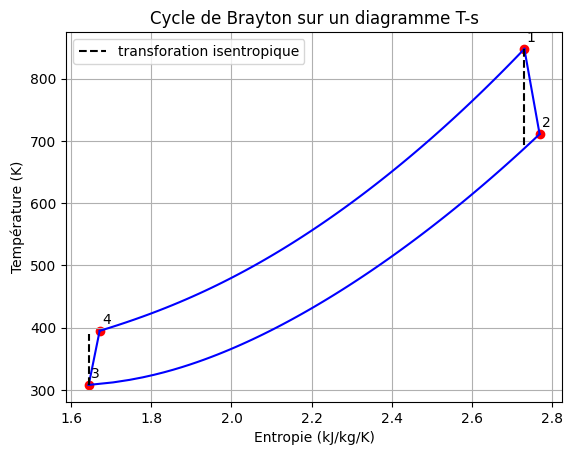

In [21]:
points_s = [s_1*1e-3, s_2*1e-3, s_3*1e-3, s_4*1e-3]
points_T = [T_1, T_2, T_3, T_4]
points_P= [P_1, P_2, P_3, P_4]

# Programme pour tracer les isobares
def transfo_isobare(T_in, T_out, P, n=100):
    Ss, Ts = [], []
    for t in np.linspace(T_in, T_out, n):
        try:
            s_val = CP.PropsSI("S", "P", P, "T", t, "CO2") * 1e-3  # Conversion en kJ/kg/K
            Ss.append(s_val)
            Ts.append(t)
        except:
            pass
    return [np.array(Ss), np.array(Ts)]

# Affichage des 4 points états
plt.scatter(points_s, points_T, marker='o', color='red')
for i, txt in enumerate(['1', '2', '3', '4']):
    plt.annotate(txt, (points_s[i], points_T[i]), textcoords="offset points", xytext=(5,5), ha='center')
# Tracé des isobares
S_23, T_23 = transfo_isobare( T_2, T_3, P_2)
plt.plot(S_23, T_23, color='blue')
S_41, T_41 = transfo_isobare(T_4, T_1, P_4)
plt.plot(S_41, T_41, color='blue')
# Tracé des transformations réelles
plt.plot([points_s[0], points_s[1]], [points_T[0], points_T[1]], color='blue')
plt.plot([points_s[2], points_s[3]], [points_T[2], points_T[3]], color='blue')
# Tracé des transformations isentropiques
plt.plot([points_s[0], points_s[0]], [points_T[0], T_2_is],'k--', color='black', label='transforation isentropique')
plt.plot([points_s[2], points_s[2]], [points_T[2], T_4_is], 'k--', color='black')

# Affichage du diagramme
plt.xlabel('Entropie (kJ/kg/K)')
plt.ylabel('Température (K)')
plt.title('Cycle de Brayton sur un diagramme T-s')
plt.legend()
plt.grid()
plt.show()

*$\textbf{Q-2.3 :}$ Calculer les puissances échangées (tableau 4) les rendements énergétique et exergétique.*

In [22]:
q_m = q_m_voulu # kg/s

# Echange d'énergie :
print("Echange d'énergie :",
      f"Chaudière : {q_m*(h_4_reel-h_1)*1e-6} MW",
      f"Turbine : {q_m*(h_1-h_2_reel)*1e-6} MW",
      f"Source froide :{q_m*(h_2_reel-h_3)*1e-6} MW",
      f"Compresseur : {q_m*(h_3-h_4_reel)*1e-6} MW", sep="\n")

# Puissance thermique :
q_chaude = (h_1-h_4_reel)*q_m*1e-6
q_froide = (h_3-h_2_reel)*q_m*1e-6
print("Puissance tyhermique :",
      f"Chaudière : {q_chaude} MW",
      f"Turbine : 0 MW car adiabatique",
      f"Source froide : {q_froide} MW",
      f"Compresseur : 0 MW car adiabatique", sep="\n")

# Travail utile :
w_turbine = (h_2_reel-h_1)*q_m*1e-6
w_compresseur = (h_4_reel-h_3)*q_m*1e-6
print("Travail utile :",
      f"Chaudière : 0 MW car pas de travail",
      f"Turbine : {w_turbine} MW",
      f"Source froide : 0 MW car pas de travail ",
      f"Compresseur : {w_compresseur} MW", sep="\n")

# Echange d'éxergie :
T0 = 280 #K, fixé arbitrairement selon la page 32 du cours. 
print("Echange d'éxergie :",
      f"Chaudière : {q_m*((h_4_reel-h_1)-T0*(s_4-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6} MW",
      f"Source froide :{q_m*((h_2_reel-h_3)-T0*(s_2-s_3))*1e-6} MW",
      f"Compresseur : {q_m*((h_3-h_4_reel)-T0*(s_3-s_4))*1e-6} MW", sep="\n")

# Exergie des échanges :
T_froide = 293.15 # K, source froide 
T_chaude = 873.15 # K, source chaude
eta_Carnot = 1 - T_froide / T_chaude
print("Exergie des échanges :",
      f"Chaudière : {q_chaude*eta_Carnot} MW",
      f"Source froide : {q_froide*eta_Carnot} MW",sep="\n")

# Destruction d'exergie :
print("Destruction d'exergie :",
      f"Chaudière : {q_m*((h_4_reel-h_1)-T0*(s_4-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6-w_turbine}MW",
      f"Source froide :{q_m*((h_2_reel-h_3)-T0*(s_2-s_3))*1e-6} MW",
      f"Compresseur : {q_m*((h_3-h_4_reel)-T0*(s_3-s_4))*1e-6-w_compresseur} MW", sep="\n")

Echange d'énergie :
Chaudière : -242.68683112458064 MW
Turbine : 59.733552945245364 MW
Source froide :204.19513389557005 MW
Compresseur : -21.241855716234806 MW
Puissance tyhermique :
Chaudière : 242.68683112458064 MW
Turbine : 0 MW car adiabatique
Source froide : -204.19513389557005 MW
Compresseur : 0 MW car adiabatique
Travail utile :
Chaudière : 0 MW car pas de travail
Turbine : -59.733552945245364 MW
Source froide : 0 MW car pas de travail 
Compresseur : 21.241855716234806 MW
Echange d'éxergie :
Chaudière : -125.18330310487498 MW
Turbine : 63.95243665915205 MW
Source froide :79.44020630280086 MW
Compresseur : -18.20933985707791 MW
Exergie des échanges :
Chaudière : 161.20753828352147 MW
Source froide : -135.63898260256616 MW
Destruction d'exergie :
Chaudière : -125.18330310487498 MW
Turbine : 123.6859896043974MW
Source froide :79.44020630280086 MW
Compresseur : -39.45119557331272 MW


In [23]:
w_net = w_compresseur + w_turbine        # MW
print(f"w_turbine = {w_turbine:.1f} MW")
print(f"w_compresseur = {w_compresseur:.1f} MW")
print(f"w_net = {w_net:.1f} MW")
print(f"q_chaude = {q_chaude:.1f} MW")
eta_ener = abs(w_net) / q_chaude
print(f"Le rendement énergétique est de {eta_ener:.4f} ({eta_ener:.2%}).")

w_turbine = -59.7 MW
w_compresseur = 21.2 MW
w_net = -38.5 MW
q_chaude = 242.7 MW
Le rendement énergétique est de 0.1586 (15.86%).


In [24]:
eta_Carnot = 1 - T_froide / T_chaude
print(f"Le rendement de Carnot est de {eta_Carnot:.4f} ({eta_Carnot:.2%}).")

eta_exer = eta_ener / eta_Carnot
print(f"Le rendement exergétique est de {eta_exer:.4f} ({eta_exer:.2%}).")

Le rendement de Carnot est de 0.6643 (66.43%).
Le rendement exergétique est de 0.2388 (23.88%).


In [25]:
W_net_connu = 25e6   # W_net = 25 MW
q_m_voulu = W_net_connu*q_m/ (abs(w_net)*1e6)
print(f"Le débit massique voulu est q_m_voulu = {q_m_voulu:.1f} kg/s")

Le débit massique voulu est q_m_voulu = 257.3 kg/s


## 3. Cycle $CO_{2}$ supercritique avec récupération ##

*$\textbf{Q-3.1 :}$ Recalculer les nouveaux points de fonctionnement dans le cycle intégrant l’échangeur récupérateur (tableau 5). Dessiner ce cycle sur un diagramme (T-s).*

On garde les mêmes paramètres d'état que sur le cycle précédent, c'est- à dire que les états en sortie de chaudière et en entrée du compresseur sont les mêmes que précédemment. 

In [26]:
#Définition des constantes connues :
P_1 = P_5 = P_6 = 250.e5 #Pa
T_1 = 848 #K
P_3 = P_2 = P_4 = 75.e5 #Pa
T_4 = 308 #K
#Calcul des enthalpies et entropies
h_1= CP.PropsSI("H","P",P_1,"T",T_1,"CO2")
s_1 = CP.PropsSI("S","P",P_1,"H",h_1,"CO2")
h_4 = CP.PropsSI("H","P",P_4,"T",T_4,"CO2")
s_4 = CP.PropsSI("S","P",P_4,"H",h_4,"CO2")
print(f"h_1: {h_1*1e-3} kJ/kg", f"s_1: {s_1*1e-3} kJ/kg/K", f"h_3: {h_4*1e-3} kJ/kg", f"s_3: {s_4*1e-3} kJ/kg/K", sep="\n")

h_1: 1063.014453019842 kJ/kg
s_1: 2.730546625535663 kJ/kg/K
h_3: 396.7403555037961 kJ/kg
s_3: 1.6438076710686962 kJ/kg/K


In [27]:
## TRANSFORMATION 1-2 ----------------------------------------------
# Transformation supposée isentropique : s_2 = s_1  
T_2_is = CP.PropsSI("T", "P", P_2, "S", s_1, "CO2")
print(f"T_2_is = {T_2_is:.2f} K  ({T_2_is - 273.15:.2f} °C)")
h_2_is= CP.PropsSI("H","P",P_2,"T",T_2_is,"CO2")
print(f"h_2_is: {h_2_is*1e-3} kJ/kg")

# Transformation réelle
eta_t = 0.85 # rendement isentropique turbine 
h_2_reel = h_1 - eta_t * (h_1 - h_2_is)
print(f"h_2_reel: {h_2_reel*1e-3} kJ/kg")
T_2 = CP.PropsSI("T", "P", P_2, "H", h_2_reel, "CO2")
print(f"T_2 = {T_2:.2f} K  ({T_2 - 273.15:.2f} °C)")
s_2 = CP.PropsSI("S","P",P_2,"H",h_2_reel,"CO2")
print(f"s_2: {s_2*1e-3} kJ/kg/K")

T_2_is = 688.23 K  (415.08 °C)
h_2_is: 885.6094944999654 kJ/kg
h_2_reel: 912.2202382779469 kJ/kg
T_2 = 711.07 K  (437.92 °C)
s_2: 2.7685835904859677 kJ/kg/K


In [28]:
## TRANSFORMATION 4-5 ----------------------------------------------
# Transformation supposée isentropique : s_4 = s_5 
T_5_is = CP.PropsSI("T", "P", P_5, "S", s_4, "CO2")
print(f"T_5_is = {T_5_is:.2f} K  ({T_5_is - 273.15:.2f} °C)")
h_5_is= CP.PropsSI("H","P",P_5,"T",T_5_is,"CO2")
print(f"h_5_is: {h_5_is*1e-3} kJ/kg")

# Transformation réelle
eta_c = 0.8 # rendement isentropique compresseur 
h_5_reel = h_4 + (h_5_is - h_4)/eta_c
print(f"h_5_reel: {h_5_reel*1e-3} kJ/kg")
T_5 = CP.PropsSI("T", "P", P_5, "H", h_5_reel, "CO2")
print(f"T_5 = {T_5:.2f} K  ({T_5 - 273.15:.2f} °C)")
s_5 = CP.PropsSI("S","P",P_5,"H",h_5_reel,"CO2")
print(f"s_5: {s_5*1e-3} kJ/kg/K")

T_5_is = 389.65 K  (116.50 °C)
h_5_is: 439.6395141100343 kJ/kg
h_5_reel: 450.3643037615939 kJ/kg
T_5 = 394.91 K  (121.76 °C)
s_5: 1.6711484814033764 kJ/kg/K


On veut un pincement minimal de 10 °C. 
De plus, on sait que le fluide chaud arrive au point 2, tandis que le fluide froid arrive au point 5. 
On suppose le pincement atteint du côté chaud.
On veut donc T3-T5 = 10.  
On choisit donc T3 = T5 + 10. 


In [29]:
T_3 = T_5+10

h_3 = CP.PropsSI("H","P",P_3,"T",T_3,"CO2")
s_3 = CP.PropsSI("S","P",P_3,"H",h_3,"CO2")
print(f"h_3: {h_3*1e-3} kJ/kg", f"s_3: {s_3*1e-3} kJ/kg/K", sep="\n")
print(f"T_3 = {T_3:.2f} K  ({T_3 - 273.15:.2f} °C)")

h_3: 562.9576277783641 kJ/kg
s_3: 2.126336581874877 kJ/kg/K
T_3 = 404.91 K  (131.76 °C)


Par bilan sur l'échangeur on obtient la relation suivante : h_6 - h_5 = h_2 - h_3. On peut donc à présent calculer les valeurs du point 6

In [30]:
h_6 = h_5_reel + h_2_reel -h_3
T_6 = CP.PropsSI("T", "P", P_6, "H", h_6, "CO2")
s_6 = CP.PropsSI("S","P",P_6,"H",h_6,"CO2")

print(f"T_6 = {T_6:.2f} K  ({T_6 - 273.15:.2f} °C)")
print(f"s_6: {s_6*1e-3} kJ/kg/K")
print(f"h_6: {h_6*1e-3} kJ/kg")

T_6 = 637.27 K  (364.12 °C)
s_6: 2.3735063502507256 kJ/kg/K
h_6: 799.6269142611767 kJ/kg


/var/folders/bv/ykzk9d_14271yt6j934j38jw0000gn/T/ipykernel_11052/2772731291.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([points_s[0], points_s[0]], [points_T[0], T_2_is],'k--', color='black', label='transforation isentropique')
/var/folders/bv/ykzk9d_14271yt6j934j38jw0000gn/T/ipykernel_11052/2772731291.py:36: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([points_s[3], points_s[3]], [points_T[3], T_5_is], 'k--', color='black')


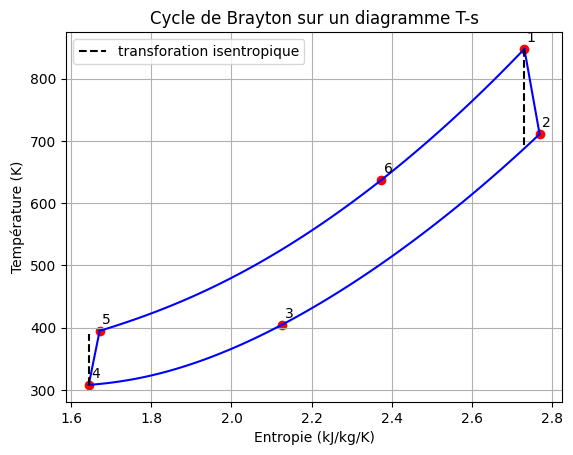

In [31]:
points_s = [s_1*1e-3, s_2*1e-3, s_3*1e-3, s_4*1e-3, s_5*1e-3, s_6*1e-3]
points_T = [T_1, T_2, T_3, T_4, T_5, T_6]
points_P= [P_1, P_2, P_3, P_4, P_5, P_6]

# Programme pour tracer les isobares
def transfo_isobare(T_in, T_out, P, n=100):
    Ss, Ts = [], []
    for t in np.linspace(T_in, T_out, n):
        try:
            s_val = CP.PropsSI("S", "P", P, "T", t, "CO2") * 1e-3  # Conversion en kJ/kg/K
            Ss.append(s_val)
            Ts.append(t)
        except:
            pass
    return [np.array(Ss), np.array(Ts)]

# Affichage des 6 points états
plt.scatter(points_s, points_T, marker='o', color='red')
for i, txt in enumerate(['1', '2', '3', '4', '5', '6']):
    plt.annotate(txt, (points_s[i], points_T[i]), textcoords="offset points", xytext=(5,5), ha='center')
# Tracé des isobares
S_23, T_23 = transfo_isobare( T_2, T_3, P_2)
plt.plot(S_23, T_23, color='blue')
S_34, T_34 = transfo_isobare( T_3, T_4, P_3)
plt.plot(S_34, T_34, color='blue')
S_56, T_56 = transfo_isobare(T_5, T_6, P_5)
plt.plot(S_56, T_56, color='blue')
S_61, T_61 = transfo_isobare(T_6, T_1, P_6)
plt.plot(S_61, T_61, color='blue')

# Tracé des transformations réelles
plt.plot([points_s[0], points_s[1]], [points_T[0], points_T[1]], color='blue')
plt.plot([points_s[3], points_s[4]], [points_T[3], points_T[4]], color='blue')
# Tracé des transformations isentropiques
plt.plot([points_s[0], points_s[0]], [points_T[0], T_2_is],'k--', color='black', label='transforation isentropique')
plt.plot([points_s[3], points_s[3]], [points_T[3], T_5_is], 'k--', color='black')

# Affichage du diagramme
plt.xlabel('Entropie (kJ/kg/K)')
plt.ylabel('Température (K)')
plt.title('Cycle de Brayton sur un diagramme T-s')
plt.legend()
plt.grid()
plt.show()

*$\textbf{Q-3.2 :}$ Faire les bilans des différents composants (tableau 6) et recalculer les débits requis, rendements énergétique et exergétique, puissance thermique transférée et efficacité de l’échangeur récupérateur.*

In [32]:
q_m = q_m_voulu # kg/s

# Echange d'énergie :
print("Echange d'énergie :",
      f"Chaudière : {q_m*(h_6-h_1)*1e-6} MW",
      f"Turbine : {q_m*(h_1-h_2_reel)*1e-6} MW",
      f"Source froide :{q_m*(h_3-h_4)*1e-6} MW",
      f"Compresseur : {q_m*(h_4-h_5_reel)*1e-6} MW",
      f"Recuperateur : {q_m*(h_2_reel+h_5_reel-h_3-h_6)*1e-6}", sep="\n")

# Puissance thermique :
q_chaude = (h_1-h_6)*q_m*1e-6
q_froide = (h_4-h_3)*q_m*1e-6
print("Puissance tyhermique :",
      f"Chaudière : {q_chaude} MW",
      f"Source froide : {q_froide} MW",
      f"Recuperateur : {q_m*(h_3-h_2_reel)*1e-6}", sep="\n")

# Travail utile :
w_turbine = (h_2_reel-h_1)*q_m*1e-6
w_compresseur = (h_5_reel-h_4)*q_m*1e-6
print("Travail utile :",
      f"Turbine : {w_turbine} MW",
      f"Compresseur : {w_compresseur} MW", sep="\n")

# Echange d'éxergie :
T0 = 280 #K, fixé arbitrairement selon la page 32 du cours. 
print("Echange d'éxergie :",
      f"Chaudière : {q_m*((h_6-h_1)-T0*(s_6-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6} MW",
      f"Source froide :{q_m*((h_3-h_4)-T0*(s_3-s_4))*1e-6} MW",
      f"Compresseur : {q_m*((h_4-h_5_reel)-T0*(s_4-s_5))*1e-6} MW",
      f"Recuperateur : {q_m*(h_2_reel+h_5_reel-h_3-h_6)-T0*(s_2+s_5-s_3-s_6)*1e-6} MW",  sep="\n")

# Exergie des échanges :
T_froide = 293.15 # K, source froide 
T_chaude = 873.15 # K, source chaude
eta_Carnot = 1 - T_froide / T_chaude
print("Exergie des échanges :",
      f"Chaudière : {q_chaude*eta_Carnot} MW",
      f"Source froide : {q_froide*eta_Carnot} MW",
      f"Recuperateur : {q_m*(h_3-h_2_reel)*1e-6*eta_Carnot}",sep="\n")

# Destruction d'exergie :
print("Destruction d'exergie :",
      f"Chaudière : {q_m*((h_6-h_1)-T0*(s_6-s_1))*1e-6} MW",
      f"Turbine : {q_m*((h_1-h_2_reel)-T0*(s_1-s_2))*1e-6-w_turbine}MW",
      f"Source froide :{q_m*((h_3-h_4)-T0*(s_3-s_4))*1e-6} MW",
      f"Compresseur : {q_m*((h_4-h_5_reel)-T0*(s_4-s_5))*1e-6-w_compresseur} MW",
      f"Recuperateur : {q_m*(h_2_reel+h_5_reel-h_3-h_6)-T0*(s_2+s_5-s_3-s_6)*1e-6} MW", sep="\n")

Echange d'énergie :
Chaudière : -67.76443769498432 MW
Turbine : 38.79638808198952 MW
Source froide :42.76443769498432 MW
Compresseur : -13.79638808198952 MW
Recuperateur : 0.0
Puissance tyhermique :
Chaudière : 67.76443769498432 MW
Source froide : -42.76443769498432 MW
Recuperateur : -89.85840605797416
Travail utile :
Turbine : -38.79638808198952 MW
Compresseur : 13.79638808198952 MW
Echange d'éxergie :
Chaudière : -42.043792713491015 MW
Turbine : 41.53651388678709 MW
Source froide :8.003779956168144 MW
Compresseur : -11.826797184818492 MW
Recuperateur : 0.016831040866152325 MW
Exergie des échanges :
Chaudière : 45.01331256151968 MW
Source froide : -28.406773020776395 MW
Recuperateur : -59.68948693079656
Destruction d'exergie :
Chaudière : -42.043792713491015 MW
Turbine : 80.33290196877661MW
Source froide :8.003779956168144 MW
Compresseur : -25.62318526680801 MW
Recuperateur : 0.016831040866152325 MW


In [33]:
#rendement energie
w_net = w_compresseur + w_turbine        # MW
print(f"w_turbine = {w_turbine:.1f} MW")
print(f"w_compresseur = {w_compresseur:.1f} MW")
print(f"w_net = {w_net:.1f} MW")
print(f"q_chaude = {q_chaude:.1f} MW")
eta_ener = abs(w_net) / q_chaude
print(f"Le rendement énergétique est de {eta_ener:.4f} ({eta_ener:.2%}).")
# rendement exergie
eta_Carnot = 1 - T_froide / T_chaude
print(f"Le rendement de Carnot est de {eta_Carnot:.4f} ({eta_Carnot:.2%}).")
eta_exer = eta_ener / eta_Carnot
print(f"Le rendement exergétique est de {eta_exer:.4f} ({eta_exer:.2%}).")


w_turbine = -38.8 MW
w_compresseur = 13.8 MW
w_net = -25.0 MW
q_chaude = 67.8 MW
Le rendement énergétique est de 0.3689 (36.89%).
Le rendement de Carnot est de 0.6643 (66.43%).
Le rendement exergétique est de 0.5554 (55.54%).


In [34]:
W_net_connu = 25e6   # W_net = 25 MW
q_m_voulu = W_net_connu*q_m/ (abs(w_net)*1e6)
print(f"Le débit massique voulu est q_m_voulu = {q_m_voulu:.1f} kg/s")

Le débit massique voulu est q_m_voulu = 257.3 kg/s


In [35]:
h_3_max = CP.PropsSI("H", "P", P_3, "T", T_5, "CO2")*1e-3
epsilon = (h_2_reel-h_3)/(h_2_reel-h_3_max)
print(f"L'efficacité du récupérateur est : {epsilon:.4f} ({epsilon:.2%}).")

L'efficacité du récupérateur est : 0.3831 (38.31%).


## 4. Cycle $CO_{2}$ supercritique ${Turbine Split Flow}$ ##

*$\textbf{Q-4.1 :}$ Recalculer les nouveaux points de fonctionnement dans le cycle intégrant l’échangeur récupérateur (tableau 7). Dessiner ce cycle sur un diagramme (T-s).*

Les états 1 et 2 sont les mêmes que précédemment. On ne les recalcule donc pas. 
De même les états 4 et 5 sont identiques à la question précedente. 

In [ ]:
#Définition des constantes connues :
P_1 = P_5 = P_6 = P_7 =250.e5 #Pa
T_1 = 848 #K
P_2 = P_3 = P_4 = P_8= P_9 = P_10= 75.e5 #Pa
T_4 = 308 #K
T_5 = T_5


On s'intéresse à la transformation 2-10 dans le HTR : En faisant la même hypothèse que précédemment c'est à dire que le pincement se fait du côté chaud, on a : T10-T5=10 donc T10=T5+10.

In [37]:
T_10 = T_5 + 10
print(f"T_10 = {T_10:.2f} K  ({T_10 - 273.15:.2f} °C)")
h_10 = CP.PropsSI("H","P",P_10,"T",T_10,"CO2")
s_10 = CP.PropsSI("S","P",P_10,"H",h_10,"CO2")
print(f"h_10: {h_10*1e-3} kJ/kg", f"s_10: {s_3*1e-3} kJ/kg/K", sep="\n")


T_10 = 404.91 K  (131.76 °C)
h_10: 562.9576277783641 kJ/kg
s_10: 2.126336581874877 kJ/kg/K


De même dans le LTR : T9-T5 = 10, donc T9 = T5 + 10. 

In [38]:
T_9 = T_5 + 10
print(f"T_9 = {T_9:.2f} K  ({T_9 - 273.15:.2f} °C)")
h_9= CP.PropsSI("H","P",P_9,"T",T_9,"CO2")
s_9 = CP.PropsSI("S","P",P_9,"H",h_9,"CO2")
print(f"h_9: {h_9*1e-3} kJ/kg", f"s_9: {s_9*1e-3} kJ/kg/K", sep="\n")

T_3 = 0.75*T_10 + 0.25*T_9 # on suppose que le mélange est idéal
print(f"T_3 = {T_3:.2f} K  ({T_3 - 273.15:.2f} °C)")
h_3 = CP.PropsSI("H","P",P_3,"T",T_3,"CO2")
s_3 = CP.PropsSI("S","P",P_3,"H",h_3,"CO2")
print(f"h_3: {h_3*1e-3} kJ/kg", f"s_3: {s_3*1e-3} kJ/kg/K", sep="\n")

T_9 = 404.91 K  (131.76 °C)
h_9: 562.9576277783641 kJ/kg
s_9: 2.126336581874877 kJ/kg/K
T_3 = 404.91 K  (131.76 °C)
h_3: 562.9576277783641 kJ/kg
s_3: 2.126336581874877 kJ/kg/K


Transformation 5->7 dans le HTR: 
Par bilan sur l'échangeur on obtient la relation suivante : qm1(h_7 - h_5) = qm (h_2 - h_10). On peut donc à présent calculer les valeurs du point 7.

In [41]:
h_7 = h_5_reel + 1/25 * (h_2_reel - h_10)

T_7 = CP.PropsSI("T", "P", P_7, "H", h_7, "CO2")
s_7 = CP.PropsSI("S","P",P_7,"H",h_7,"CO2")

print(f"T_7 = {T_7:.2f} K  ({T_7 - 273.15:.2f} °C)")
print(f"s_7: {s_7*1e-3} kJ/kg/K")
print(f"h_7: {h_7*1e-3} kJ/kg")

T_7 = 401.98 K  (128.83 °C)
s_7: 1.7062137720512218 kJ/kg/K
h_7: 464.3348081815772 kJ/kg


Transformation 7 -> 8: Dans la turbine secondaire


In [44]:
## TRANSFORMATION 7-8 ----------------------------------------------
# Transformation supposée isentropique : s_8 = s_7  
T_8_is = CP.PropsSI("T", "P", P_8, "S", s_7, "CO2")
print(f"T_8_is = {T_8_is:.2f} K  ({T_8_is - 273.15:.2f} °C)")
h_8_is= CP.PropsSI("H","P",P_8,"T",T_8_is,"CO2")
print(f"h_8_is: {h_8_is*1e-3} kJ/kg")

# Transformation réelle
eta_t = 0.85 # rendement isentropique turbine 
h_8_reel = h_7 - eta_t * (h_7 - h_8_is)
print(f"h_8_reel: {h_8_reel*1e-3} kJ/kg")
T_8 = CP.PropsSI("T", "P", P_8, "H", h_8_reel, "CO2")
print(f"T_8 = {T_8:.2f} K  ({T_8 - 273.15:.2f} °C)")
s_8 = CP.PropsSI("S","P",P_8,"H",h_8_reel,"CO2")
print(f"s_8: {s_8*1e-3} kJ/kg/K")

T_8_is = 312.19 K  (39.04 °C)
h_8_is: 416.08014242886435 kJ/kg
h_8_reel: 423.3183422917713 kJ/kg
T_8 = 314.36 K  (41.21 °C)
s_8: 1.7293206501751857 kJ/kg/K


Transformation 5->6:
Dans le LTR, par bilan sur l'échangeur on obtient la relation suivante : qm1(h_9 - h_8) = qm2 (h_5 - h_6). On peut donc à présent calculer les valeurs du point 6.


In [46]:
h_6 = h_5_reel + 25/75 * (h_8_reel - h_9)
T_6 = CP.PropsSI("T", "P", P_6, "H", h_6, "CO2")
s_6 = CP.PropsSI("S","P",P_6,"H",h_6,"CO2")

print(f"T_6 = {T_6:.2f} K  ({T_6 - 273.15:.2f} °C)")
print(f"s_6: {s_6*1e-3} kJ/kg/K")
print(f"h_6: {h_6*1e-3} kJ/kg")


T_6 = 372.88 K  (99.73 °C)
s_6: 1.5498156888936332 kJ/kg/K
h_6: 403.8178752660629 kJ/kg


*$\textbf{Q-4.2 :}$ Faire les bilans des différents composants (tableau 8) et recalculer les débits requis, rendements énergétique et exergétique, puissance thermique transférée et efficacité dans les échangeurs HTR et LTR.*